In [57]:
pip install ucimlrepo

In [58]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
student_performance = fetch_ucirepo(id=320) 
  
# data (as pandas dataframes) 
X = student_performance.data.features 
y = student_performance.data.targets 
  
# metadata 
print(student_performance.metadata) 
  
# variable information 
print(student_performance.variables) 


{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [59]:
%pip install pandas

import pandas as pd
df = pd.read_csv('https://archive.ics.uci.edu/static/public/320/data.csv')
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


<Axes: >

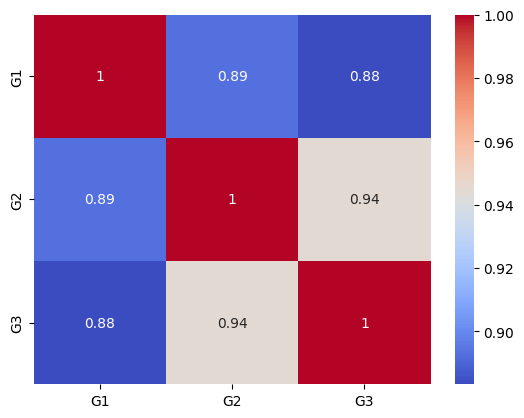

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[['G1', 'G2', 'G3']].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

In [61]:
# 1. Điểm cuối kỳ G1 có khác nhau theo giới tính (sex) không?
%pip install scipy
from scipy import stats

F_G1 = df['G1'][df['sex'] == 'F']
M_G1 = df['G1'][df['sex'] == 'M']

t_stat, p_value = stats.f_oneway(F_G1, M_G1)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 7.08940954546938, P-value: 0.007946869649724386


In [62]:
df['school'].unique()

array(['GP', 'MS'], dtype=object)

In [63]:
# 2. Điểm trung bình G3 có khác nhau giữa các trường học (school) không?
GP_G3 = df['G3'][df['school'] == 'GP']
MS_G3 = df['G3'][df['school'] == 'MS']

t_stat, p_value = stats.f_oneway(GP_G3, MS_G3)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 56.890676863371326, P-value: 1.5661990923002604e-13


In [78]:
X_train = df[['G1', 'G2']][10:]
y_train = df['G3'][10:]

X_test = df[['G1', 'G2']][:10]
y_test = df['G3'][:10]

X_train.shape

(639, 2)

In [65]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [66]:
y_pred = model.predict(X_test)

In [67]:
print(model.intercept_)
print(model.coef_)

-0.19826985340726644
[0.16053536 0.88775287]


In [75]:
X_train = df[['G1']][10:]
y_train = df['G3'][10:]

X_test = df[['G1']][:10]
y_test = df['G3'][:10]

X_train.shape

(639, 1)

In [73]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_train)

model = LinearRegression()
model.fit(X_poly,y_train)
print(model.intercept_, model.coef_)

-1.1238372048961818 [ 1.29677196 -0.01295182]


In [ ]:
from matplotlib 